In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score,precision_score,confusion_matrix
iris_data=load_iris(as_frame=True)
data,target=iris_data.data,iris_data.target
len(data)

150

In [2]:
iris_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [3]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [5]:
train_X,test_X,train_y,test_y=train_test_split(data,target,shuffle=True,random_state=42,train_size=.95)
train_X[:6],train_y[:6]

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 68                 6.2               2.2                4.5               1.5
 82                 5.8               2.7                3.9               1.2
 110                6.5               3.2                5.1               2.0
 12                 4.8               3.0                1.4               0.1
 36                 5.5               3.5                1.3               0.2
 9                  4.9               3.1                1.5               0.1,
 68     1
 82     1
 110    2
 12     0
 36     0
 9      0
 Name: target, dtype: int64)

In [6]:
model=LogisticRegression()
model.fit(train_X,train_y)
pred=model.predict(test_X)

In [7]:
recall_score(test_y,pred,average='micro')

1.0

In [8]:
precision_score(test_y,pred,average='micro')# Since we've only 150 instances, model is getting overfitted

1.0

In [9]:
confusion_matrix(test_y,pred)

array([[2, 0, 0],
       [0, 4, 0],
       [0, 0, 2]])

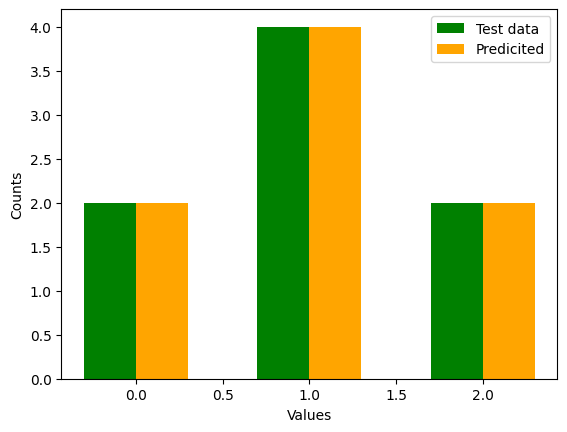

In [10]:
val,count1=np.unique(test_y,return_counts=True)
wi=0.3
plt.bar(val-wi/2,count1,width=wi,color='green',label='Test data')
val,count2=np.unique(pred,return_counts=True)
plt.bar(val+wi/2,count2,width=wi,color='Orange',label='Predicited')
plt.xlabel("Values")
plt.ylabel("Counts")
plt.legend()
plt.show()